In [6]:
using Piccolo
using SparseArrays
using Random;
Random.seed!(123);

using CairoMakie



T₀ = 10     # total time in ns
N = 50      # number of time steps
Δt = T₀ / N # time step
times = collect(range(0, T₀, length = N))

# define the system parameters
levels = 5
δ = 0.2

# add a bound to the controls
u_bound = [0.2, 0.2]
ddu_bound = 1.0

# create the system
sys = TransmonSystem(drive_bounds = u_bound, levels = levels, δ = δ)

# let's look at the drives of the system
get_drives(sys)[1] |> sparse

# define the target operator
op = EmbeddedOperator(:X, sys)

# show the full operator
op.operator |> sparse

# create a random initial pulse
initial_controls = 0.1 * randn(2, N)
pulse = ZeroOrderPulse(initial_controls, times)

# create a unitary trajectory with the embedded operator as goal
qtraj = UnitaryTrajectory(sys, pulse, op)

# create the optimization problem
qcp = SmoothPulseProblem(qtraj, N; ddu_bound = ddu_bound, Q = 100.0, R = 1e-2)

solve!(qcp; max_iter = 50)

constructing SmoothPulseProblem [UnitaryTrajectory]
QuantumControlProblem
├─ UnitaryTrajectory  ·  ZeroOrderPulse  ·  BilinearIntegrator, DerivativeIntegrator, DerivativeIntegrator
│  
├─ System
│    dim=5   drives=2
│  
├─ Trajectory
│    N=50   T=10.000   Δt∈[0, Inf]
│    Ũ⃗    (50)  ±[1.0, 1.0, 1.0, … (50 total)]  ✓  state
│    Δt   ( 1)  [0.0, Inf]                      ✓  timestep
│    t    ( 1)                                  ·  state
│    u    ( 2)  ±[0.2, 0.2]                     ✓  control
│    du   ( 2)                                  ·  control
│    ddu  ( 2)  ±[1.0, 1.0]                     ✓  control
│  
├─ Goal
│    EmbeddedOperator on [5], subspace dim 2
│  
├─ Objective   total = 61.77  @ current x
│    KnotPointObjective           w=1             61.06
│    QuadraticRegularizer(:u)     w=1             1.789e-04
│    QuadraticRegularizer(:du)    w=1             9.879e-03
│    QuadraticRegularizer(:ddu)   w=1             0.7016
│    NullObjective                w=1     

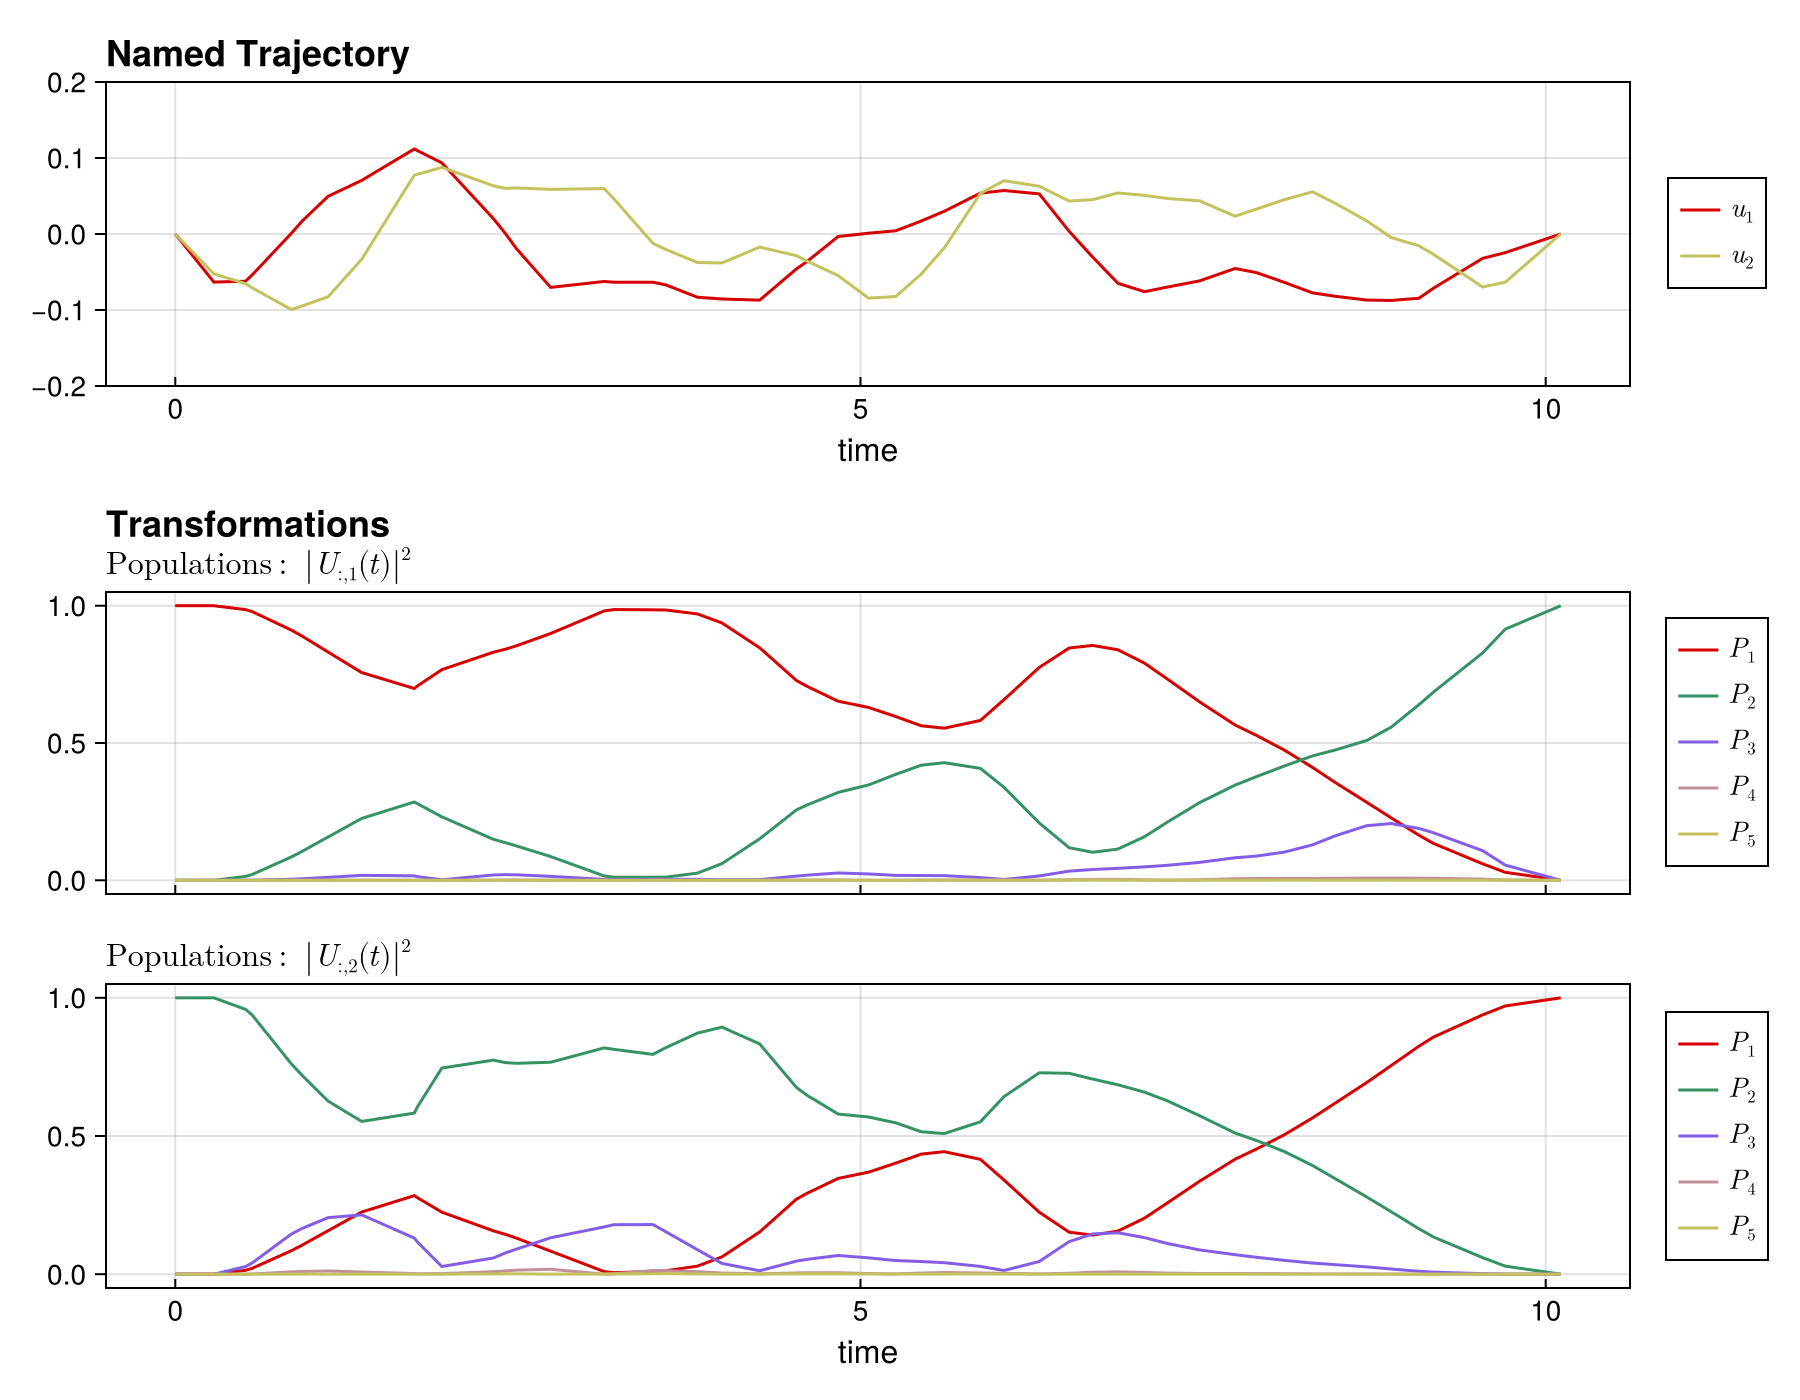

In [8]:
plot_unitary_populations(get_trajectory(qcp); fig_size = (900, 700))
